In [ ]:
# STEP 1: IMPORT LIBRARIES
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
!unzip -q "ai_dataset.zip" -d /content/


In [ ]:
train_path = "/content/ai_dataset/training"
val_path   = "/content/ai_dataset/validation"
test_path  = "/content/ai_dataset/test"


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1/255.0,
    rotation_range=40,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
)

val_gen = ImageDataGenerator(rescale=1/255.0)
test_gen = ImageDataGenerator(rescale=1/255.0)


In [ ]:
train_data = train_gen.flow_from_directory(
    "/content/ai_dataset/training",
    target_size=(128, 128),
    batch_size=8,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    "/content/ai_dataset/validation",
    target_size=(128, 128),
    batch_size=8,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    "/content/ai_dataset/test",
    target_size=(128, 128),
    batch_size=8,
    class_mode='categorical'
)


Found 120 images belonging to 3 classes.
Found 90 images belonging to 3 classes.
Found 75 images belonging to 3 classes.


CNN model construction

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD, AdamW, RMSprop

# Function to build a fresh CNN each time
def build_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
        MaxPooling2D(2,2),
        Dropout(0.25),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Dropout(0.25),

        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Dropout(0.25),

        Flatten(),

        Dense(128, activation='relu'),
        Dropout(0.5),

        Dense(3, activation='softmax')   # 3 classes
    ])
    return model

# Just to check the architecture once
model = build_model()
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Training CNN model using different optimizers

In [ ]:
import tensorflow as tf

# Early stopping (we reuse the same for all runs)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Optimizers to compare
optimizers = {
    "SGD": SGD(learning_rate=0.01, momentum=0.9),
    "Adam": Adam(learning_rate=0.001),
    "AdamW": AdamW(learning_rate=0.001, weight_decay=1e-4),
    "RMSprop": RMSprop(learning_rate=0.0005)
}

histories = {}
models = {}
test_results = {}

for name, opt in optimizers.items():
    print(f"\n===== Training model with {name} optimizer =====\n")

    # Build new model each time
    model = build_model()

    model.compile(
        loss='categorical_crossentropy',
        optimizer=opt,
        metrics=['accuracy']
    )

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=40,
        callbacks=[early_stop],
        verbose=1
    )

    # Evaluate on test set
    test_loss, test_acc = model.evaluate(test_data, verbose=0)
    print(f"{name} - Test Accuracy: {test_acc:.4f}")

    histories[name] = history
    models[name] = model
    test_results[name] = test_acc

# Pick the best optimizer based on test accuracy
best_optimizer = max(test_results, key=test_results.get)
print(f"\nBest optimizer is: {best_optimizer} with accuracy {test_results[best_optimizer]:.4f}")

# Keep the best model + its history for the rest of the notebook
model = models[best_optimizer]
history = histories[best_optimizer]



===== Training model with SGD optimizer =====



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.4351 - loss: 1.0566 - val_accuracy: 0.3444 - val_loss: 1.0882
Epoch 2/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 871ms/step - accuracy: 0.3225 - loss: 1.1336 - val_accuracy: 0.5000 - val_loss: 1.0908
Epoch 3/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 886ms/step - accuracy: 0.3912 - loss: 1.0759 - val_accuracy: 0.5222 - val_loss: 1.0523
Epoch 4/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 950ms/step - accuracy: 0.6193 - loss: 1.0199 - val_accuracy: 0.5889 - val_loss: 0.9497
Epoch 5/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 888ms/step - accuracy: 0.4609 - loss: 1.0678 - val_accuracy: 0.3333 - val_loss: 1.1098
Epoch 6/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 952ms/step - accuracy: 0.3373 - loss: 1.0986 - val_accuracy: 0.3333 - val_loss: 1.0993
Epoch 7/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 875ms/step - accuracy: 0.3558 - loss: 1.0990 - val_accuracy: 0.3333 - val_loss: 1.0981
SGD - Test Accuracy: 0.6133

===== Training model with Adam optimizer =====

Epoch 1/40
15/15 ━━━━━━

Model Setup for Transfer Learning with VGG16

In [ ]:
print("\n===== TRANSFER LEARNING: OPTIMIZER COMPARISON =====\n")

from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, AdamW, RMSprop, SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

# DATA GENERATORS (NO rescale because VGG16 expects raw pixel values for preprocess_input)
vgg_train_gen = ImageDataGenerator(preprocessing_function=None)
vgg_val_gen   = ImageDataGenerator(preprocessing_function=None)
vgg_test_gen  = ImageDataGenerator(preprocessing_function=None)

vgg_train = vgg_train_gen.flow_from_directory(
    "/content/ai_dataset/training",
    target_size=(128,128),
    batch_size=8,
    class_mode='categorical'
)

vgg_val = vgg_val_gen.flow_from_directory(
    "/content/ai_dataset/validation",
    target_size=(128,128),
    batch_size=8,
    class_mode='categorical'
)

vgg_test = vgg_test_gen.flow_from_directory(
    "/content/ai_dataset/test",
    target_size=(128,128),
    batch_size=8,
    class_mode='categorical'
)



===== TRANSFER LEARNING: OPTIMIZER COMPARISON =====

Found 120 images belonging to 3 classes.
Found 90 images belonging to 3 classes.
Found 75 images belonging to 3 classes.


Training VGG16 using different optimizers

In [ ]:
print("\n===== TRANSFER LEARNING: OPTIMIZER COMPARISON =====\n")

# IMPORTS (must be here!)
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, AdamW, RMSprop, SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

# DATA GENERATORS
vgg_train_gen = ImageDataGenerator()
vgg_val_gen   = ImageDataGenerator()
vgg_test_gen  = ImageDataGenerator()

vgg_train = vgg_train_gen.flow_from_directory(
    "/content/ai_dataset/training",
    target_size=(128,128),
    batch_size=8,
    class_mode='categorical'
)

vgg_val = vgg_val_gen.flow_from_directory(
    "/content/ai_dataset/validation",
    target_size=(128,128),
    batch_size=8,
    class_mode='categorical'
)

vgg_test = vgg_test_gen.flow_from_directory(
    "/content/ai_dataset/test",
    target_size=(128,128),
    batch_size=8,
    class_mode='categorical'
)

# BUILD VGG MODEL
def build_vgg_model():
    base_model = VGG16(
        include_top=False,
        weights='imagenet',
        input_shape=(128,128,3)
    )

    # Freeze convolution layers
    for layer in base_model.layers:
        layer.trainable = False

    # Classification head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(3, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model

# OPTIMIZERS TO TEST
vgg_optimizers = {
    "Adam": Adam(learning_rate=0.0001),
    "AdamW": AdamW(learning_rate=0.0001, weight_decay=1e-4),
    "RMSprop": RMSprop(learning_rate=0.0001),
    "SGD": SGD(learning_rate=0.001, momentum=0.9)
}

vgg_histories = {}
vgg_models = {}
vgg_results = {}

# TRAIN & COMPARE
for name, opt in vgg_optimizers.items():
    print(f"\n--- Training VGG16 with {name} optimizer ---\n")

    vgg_model_temp = build_vgg_model()
    vgg_model_temp.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    vgg_history = vgg_model_temp.fit(
        vgg_train,
        validation_data=vgg_val,
        epochs=20,
        callbacks=[early_stop],
        verbose=1
    )

    test_loss, test_acc = vgg_model_temp.evaluate(vgg_test, verbose=0)
    print(f"{name} Test Accuracy: {test_acc:.4f}")

    vgg_histories[name] = vgg_history
    vgg_models[name] = vgg_model_temp
    vgg_results[name] = test_acc

# BEST OPTIMIZER (FIXED LINE)
best_vgg_opt = max(vgg_results, key=vgg_results.get)
print(f"\nBest VGG16 Optimizer: {best_vgg_opt} with accuracy {vgg_results[best_vgg_opt]:.4f}\n")

# SAVE THE BEST MODEL & HISTORY
vgg_model = vgg_models[best_vgg_opt]
vgg_history = vgg_histories[best_vgg_opt]



===== TRANSFER LEARNING: OPTIMIZER COMPARISON =====

Found 120 images belonging to 3 classes.
Found 90 images belonging to 3 classes.
Found 75 images belonging to 3 classes.

--- Training VGG16 with Adam optimizer ---

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.2652 - loss: 9.8631 - val_accuracy: 0.4000 - val_loss: 5.1857
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.3514 - loss: 9.0791 - val_accuracy: 0.4778 - val_loss: 3.4093
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.3763 - loss: 7.3031 - val_accuracy: 0.5667 - val_loss: 2.2318
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.6242 - loss: 4.3524 - val_accuracy: 0.6444 - val_loss: 1.7183
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.5405 - loss: 4.1674 - val_accuracy: 0.7444 - val_loss: 1.3444
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.6040 - loss: 3.9584 - val_accuracy:

Optimizers comparison summary

In [ ]:
print("\n===== OPTIMIZER COMPARISON SUMMARY =====\n")

import pandas as pd

baseline_df = pd.DataFrame({
    "Optimizer": list(test_results.keys()),
    "Test Accuracy (Baseline CNN)": list(test_results.values())
})

vgg_df = pd.DataFrame({
    "Optimizer": list(vgg_results.keys()),
    "Test Accuracy (VGG16)": list(vgg_results.values())
})

# Merge results
comparison_df = pd.merge(baseline_df, vgg_df, on="Optimizer", how="outer")

print(comparison_df)



===== OPTIMIZER COMPARISON SUMMARY =====

  Optimizer  Test Accuracy (Baseline CNN)  Test Accuracy (VGG16)
0      Adam                      0.786667               0.893333
1     AdamW                      0.826667               0.893333
2   RMSprop                      0.706667               0.866667
3       SGD                      0.613333               0.946667


Optimizers performance comparison chart

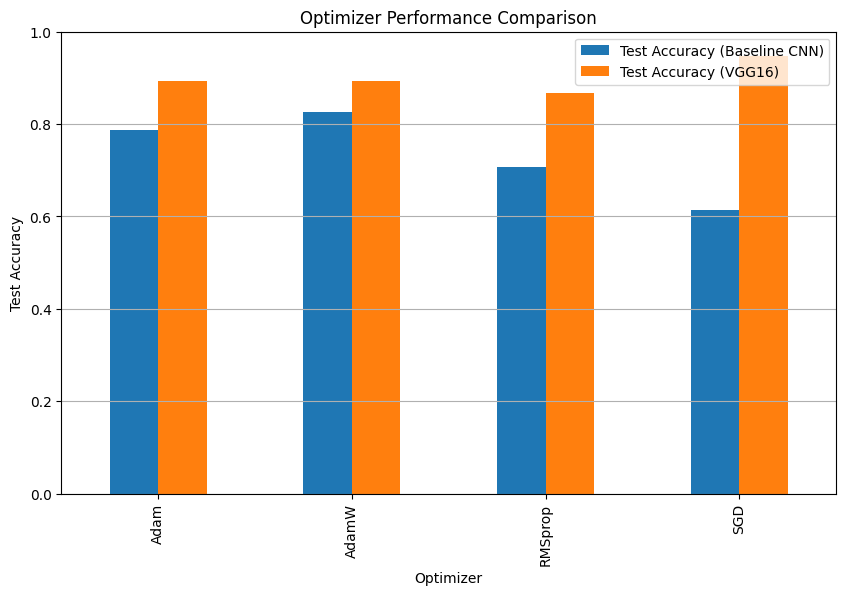

In [ ]:
comparison_df.set_index("Optimizer").plot(kind="bar", figsize=(10,6))
plt.title("Optimizer Performance Comparison")
plt.ylabel("Test Accuracy")
plt.ylim(0,1)
plt.grid(axis="y")
plt.savefig("optimizer_comparison.png", dpi=300)
plt.show()


Evaluation : accuracy and loss curve for baseline CNN

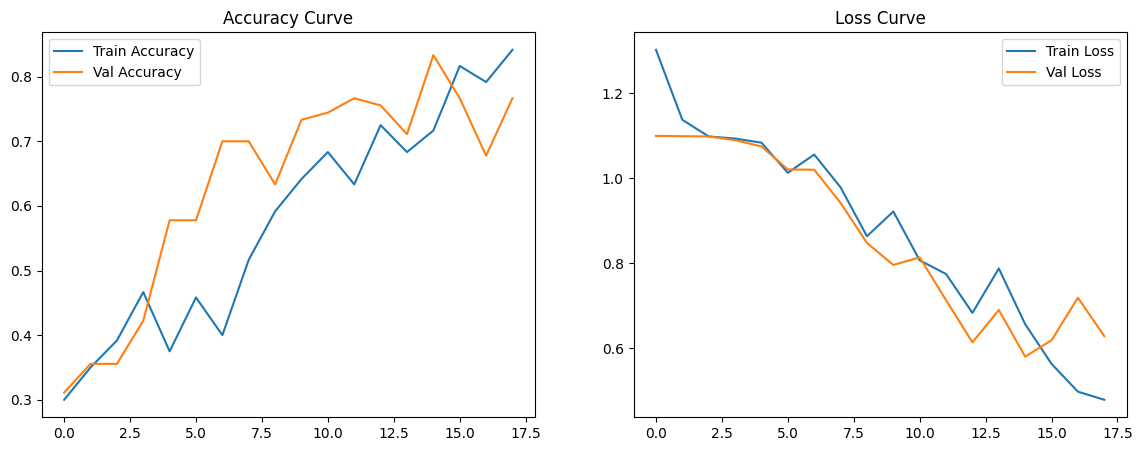

In [ ]:
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curve')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()

# SAVE GRAPH
plt.savefig("training_curves.png", dpi=300)

plt.show()


In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)


10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 343ms/step - accuracy: 0.8183 - loss: 0.5448
Test Accuracy: 0.8266666531562805
Test Loss: 0.5336080193519592


Evaluation : loss and accuracy curve for VGG16

Best VGG16 Optimizer: SGD with accuracy 0.9467


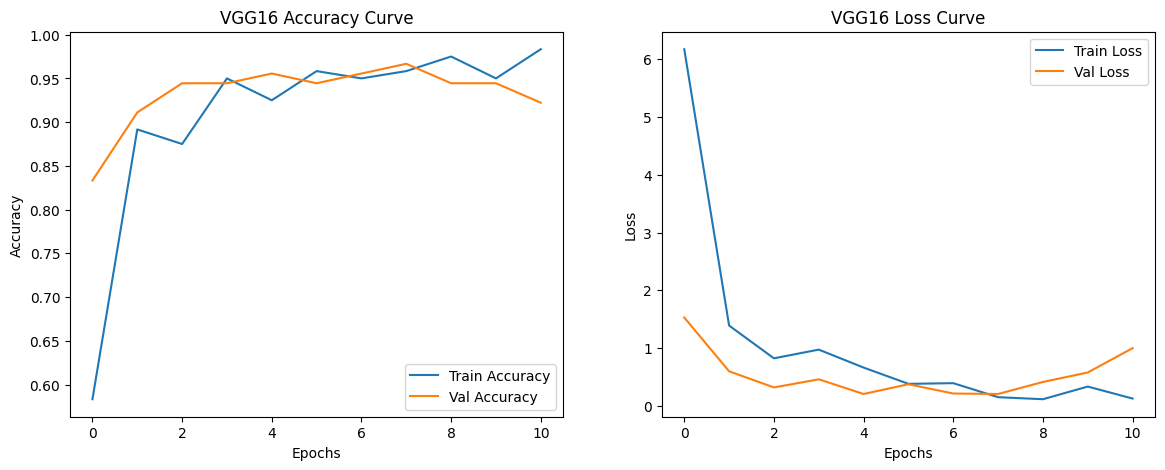

In [ ]:
# ==== VGG16 – SELECT BEST MODEL + PLOT TRAINING CURVES ====

# 1. Imports (safe to re-run)
import matplotlib.pyplot as plt
import numpy as np

# 2. Pick the best optimizer based on test accuracy
#    (vgg_results was filled in your VGG16 training loop)
best_vgg_opt = max(vgg_results, key=vgg_results.get)
print(f"Best VGG16 Optimizer: {best_vgg_opt} with accuracy {vgg_results[best_vgg_opt]:.4f}")

# 3. Retrieve the best model and its training history
vgg_model   = vgg_models[best_vgg_opt]
vgg_history = vgg_histories[best_vgg_opt]

# 4. Plot accuracy and loss curves for VGG16
plt.figure(figsize=(14,5))

# ---- Accuracy curve ----
plt.subplot(1, 2, 1)
plt.plot(vgg_history.history['accuracy'],     label='Train Accuracy')
plt.plot(vgg_history.history['val_accuracy'], label='Val Accuracy')
plt.title('VGG16 Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# ---- Loss curve ----
plt.subplot(1, 2, 2)
plt.plot(vgg_history.history['loss'],     label='Train Loss')
plt.plot(vgg_history.history['val_loss'], label='Val Loss')
plt.title('VGG16 Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# 5. Save and show the figure
plt.savefig("vgg16_training_curves.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# ==== Evaluate VGG16 on Test Set ====

# Make sure the test generator is reset
vgg_test.reset()

# Evaluate
vgg_test_loss, vgg_test_acc = vgg_model.evaluate(vgg_test, verbose=1)

# Print results
print("VGG16 Test Accuracy:", vgg_test_acc)
print("VGG16 Test Loss:", vgg_test_loss)


10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.9571 - loss: 0.3176
VGG16 Test Accuracy: 0.9466666579246521
VGG16 Test Loss: 0.4020286798477173


Sample example

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
Image 1 — True: 0, Predicted: 0


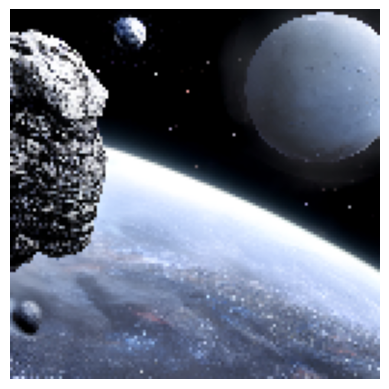

Image 2 — True: 2, Predicted: 2


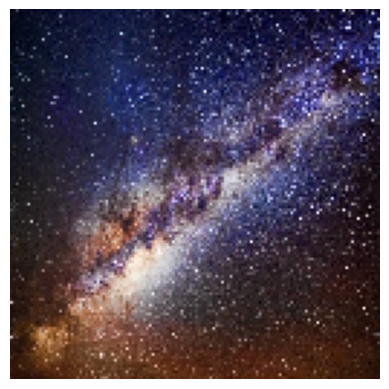

Image 3 — True: 2, Predicted: 2


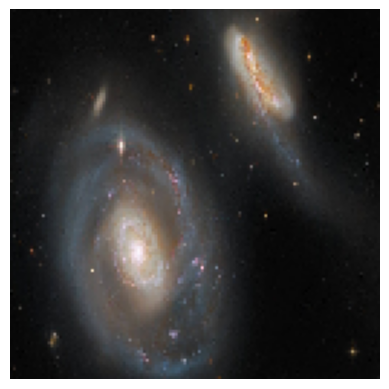

Image 4 — True: 1, Predicted: 1


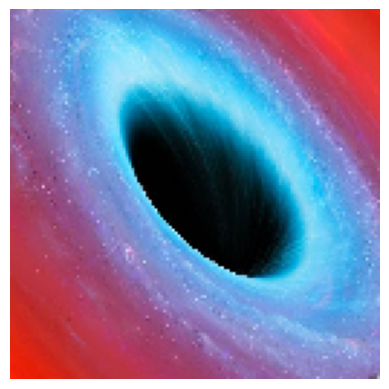

Image 5 — True: 2, Predicted: 2


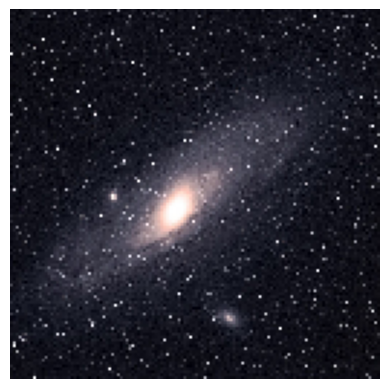

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Get a single batch from test_data
test_images, test_labels = next(iter(test_data))

# Predict
predictions = model.predict(test_images)

# Show the first 5 predictions
for i in range(5):
    plt.imshow(test_images[i])
    plt.axis('off')
    true_label = np.argmax(test_labels[i])
    pred_label = np.argmax(predictions[i])
    print(f"Image {i+1} — True: {true_label}, Predicted: {pred_label}")
    plt.show()


In [ ]:
print(train_data.class_indices)


{'asteroid': 0, 'black_hole': 1, 'galaxy': 2}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


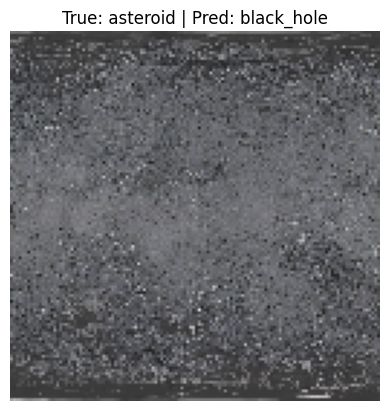

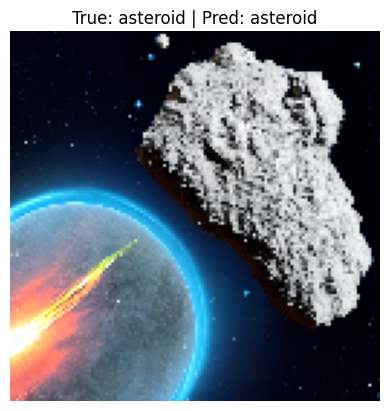

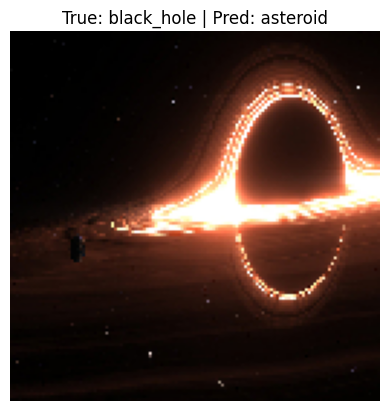

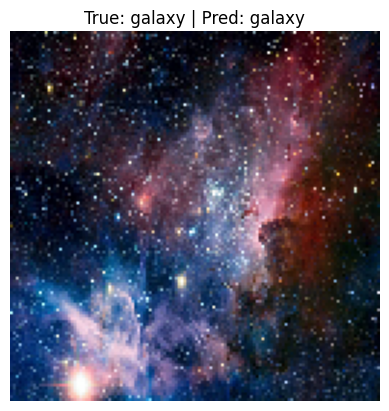

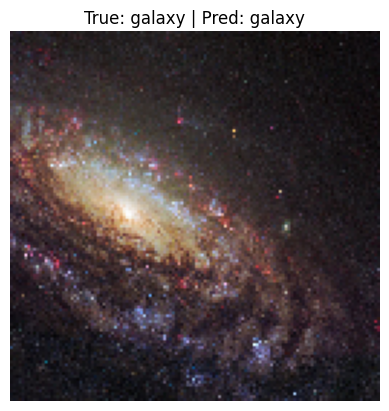

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get class labels (asteroid, black_hole, galaxy)
labels = list(train_data.class_indices.keys())

# Get a batch from test set
test_images, test_labels = next(iter(test_data))

# Predict on that batch
predictions = model.predict(test_images)

# Show and save first 5 predictions
for i in range(5):

    # Display the image
    plt.imshow(test_images[i])
    plt.axis('off')

    # Determine true and predicted classes
    true_class = labels[np.argmax(test_labels[i])]
    pred_class = labels[np.argmax(predictions[i])]

    # Add title
    plt.title(f"True: {true_class} | Pred: {pred_class}")

    #  THIS IS WHERE YOUR SAVE CODE GOES
    plt.savefig(f"prediction_{i}.png", dpi=300)

    # Show image in notebook
    plt.show()

Metrics for evaluating baseline CNN

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Collect true and predicted labels for the whole test set
y_true = []
y_pred = []

test_data.reset()

for i in range(len(test_data)):
    images, labels = next(test_data)
    preds = model.predict(images)

    y_true.extend(np.argmax(labels, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(train_data.class_indices.keys())))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Classification Report:

              precision    recall  f1-score   support

    asteroid       0.80      0.80      0.80        25
  black_hole       0.79      0.76      0.78        25
      galaxy       0.88      0.92      0.90        25

    accuracy                           0.83        75
   macro avg       0.83      0.83      0.83        75
weighted avg       0.83      0.83      0.83        75



Baseline CNN : confusion matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


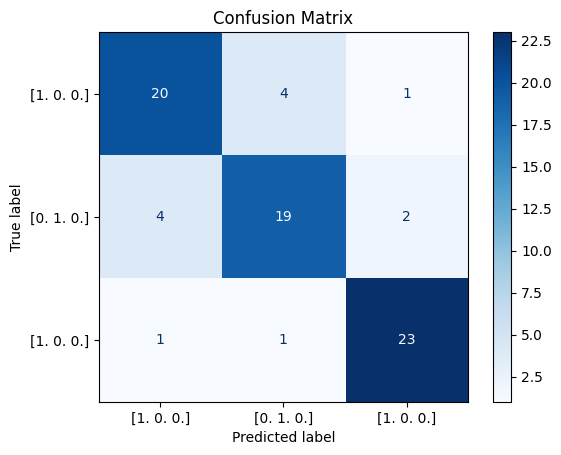

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Get true and predicted labels for the whole test set
y_true = []
y_pred = []

test_data.reset()  # important so Keras starts from beginning

for i in range(len(test_data)):
    images, labels = next(test_data)
    preds = model.predict(images)

    y_true.extend(np.argmax(labels, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display it
disp = ConfusionMatrixDisplay(cm, display_labels=labels)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300)

plt.show()


Metrics for evaluating VGG16

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Reset test generator
vgg_test.reset()

# True and predicted labels
y_true = []
y_pred = []

for i in range(len(vgg_test)):
    images, labels = next(vgg_test)
    preds = vgg_model.predict(images)

    y_true.extend(np.argmax(labels, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# Class labels
class_names = list(train_data.class_indices.keys())

# PRINT CLASSIFICATION REPORT
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=2
)

print("===== VGG16 CLASSIFICATION REPORT =====\n")
print(report)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 974ms/step
===== VGG16 CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

    asteroid       0.92      0.92      0.92        25
  black_hole       1.00      0.92      0.96        25
      galaxy       0.93      1.00      0.96        25

    accuracy                           0.95        75
   macro avg       0.95      0.95      0.95        75
weighted avg       0.95      0.95      0.95        75



VGG16 : Confusion matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step


<Figure size 800x600 with 0 Axes>

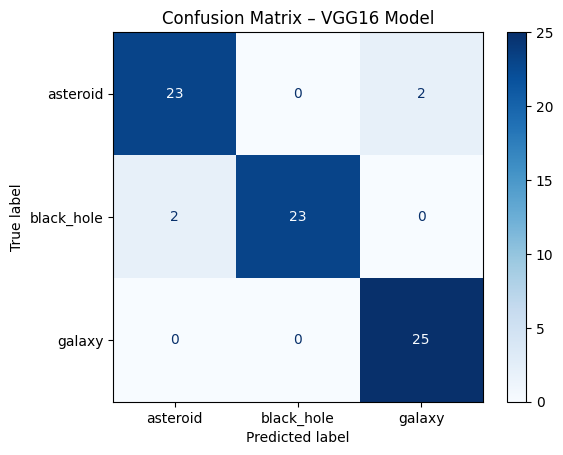

<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Reset test generator
vgg_test.reset()

# True and predicted labels
y_true = []
y_pred = []

for i in range(len(vgg_test)):
    images, labels = next(vgg_test)
    preds = vgg_model.predict(images)

    y_true.extend(np.argmax(labels, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# Class names
class_names = list(train_data.class_indices.keys())

# Create confusion matrix
cm_vgg = confusion_matrix(y_true, y_pred)

# Display confusion matrix
plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_vgg, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix – VGG16 Model")
plt.grid(False)
plt.show()

# Save confusion matrix
plt.savefig("vgg16_confusion_matrix.png", dpi=300, bbox_inches='tight')


Features map


===== FEATURE MAP VISUALIZATION =====

Using layer: conv2d_9
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


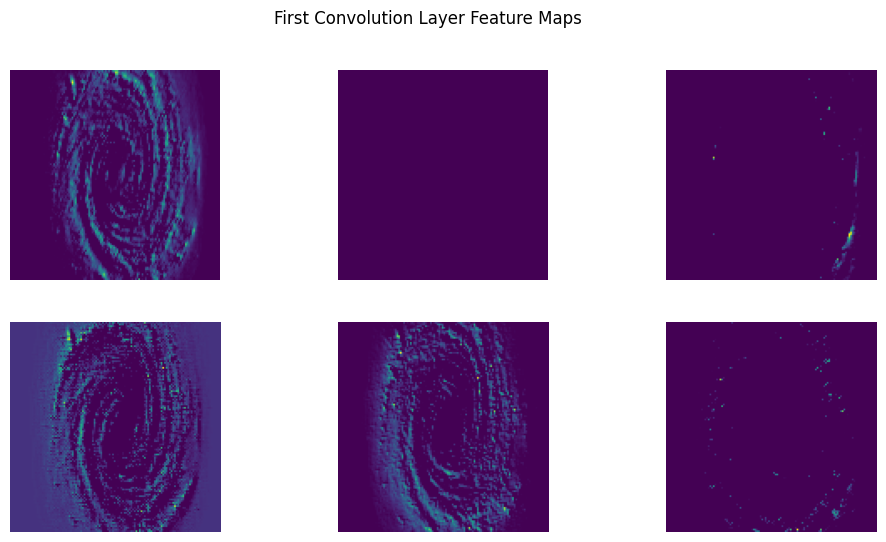

In [ ]:
print("\n===== FEATURE MAP VISUALIZATION =====\n")

from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import numpy as np

# Pick the first convolution layer of your CNN
first_conv_layer = [layer.name for layer in model.layers if "conv" in layer.name][0]
print("Using layer:", first_conv_layer)

# Get one batch from test set
test_images, test_labels = next(iter(test_data))

# Call the model once so .input becomes available
_ = model.predict(test_images[:1])

# Build model to output the selected conv layer
feature_model = Model(
    inputs=model.layers[0].input,
    outputs=model.get_layer(first_conv_layer).output
)

# Prepare a test image
img = test_images[0].reshape(1,128,128,3)

# Extract feature maps
feature_maps = feature_model.predict(img)

# Display 6 feature maps
plt.figure(figsize=(12,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap='viridis')
    plt.axis('off')

plt.suptitle("First Convolution Layer Feature Maps")
plt.savefig("feature_maps.png", dpi=300)
plt.show()
